## Model Evaluation — Nigerian Credit Risk Pipeline

### Objective
Deep evaluation of the champion XGBoost model using credit risk specific 
metrics. This notebook goes beyond accuracy to answer the business question:

*"At what threshold should a Nigerian digital lender approve or reject a loan 
application to minimise default risk while maintaining a healthy approval rate?"*

### Evaluation Framework
- **ROC-AUC** — overall discrimination power of the model
- **KS Statistic** — industry standard for credit scorecard validation,
  measures separation between good and bad borrowers
- **Confusion Matrix at multiple thresholds** — shows the business tradeoff 
  between catching defaulters and approving good borrowers
- **Feature Importance** — identifies which borrower signals drive default risk
- **Business Impact** — translates model performance into fintech business metrics

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

## ROC-AUC

In [2]:
# Load best model
model = joblib.load('../models/best_model_xgb.pkl')

# Load features
df = pd.read_csv('../data/features/loan_features.csv')

# Recreate exact same split as notebook 04
numerical = list(df.select_dtypes(include=['int64', 'float64']).columns)
if 'default_flag' in numerical:
    numerical.remove('default_flag')

categorical = list(df.select_dtypes(include=['object', 'str']).columns)

X = df[numerical + categorical]
y = df['default_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Generate predicted probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Test set: {X_test.shape[0]} borrowers")
print(f"Default rate in test set: {y_test.mean():.2%}")
print(f"Best model AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Test set: 11545 borrowers
Default rate in test set: 20.19%
Best model AUC: 0.7223


In [3]:
# calculate the false positive rate, true positive rate and the thresholds using roc_curve from sklearn
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

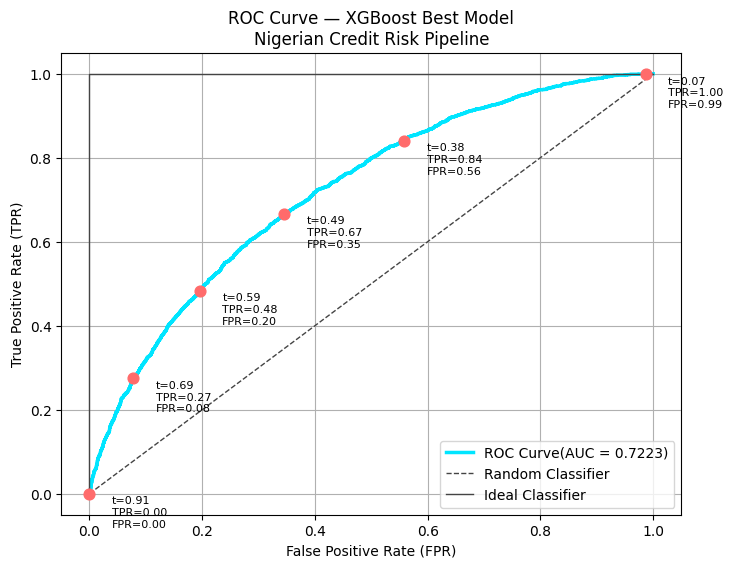


   Threshold     TPR     FPR
--------------------------------
      0.9101  0.0004  0.0000
      0.6913  0.2746  0.0779
      0.5909  0.4835  0.1956
      0.4937  0.6671  0.3460
      0.3849  0.8408  0.5584
      0.0748  1.0000  0.9868


In [4]:
# pick 6 indices to annotate on the curve
num_annotations = 6
annotate_indices = np.linspace(1, len(thresholds) -2, num_annotations, dtype=int)

# create the plot(the ideal classifier, the random classifier and our model classifier)
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(fpr, tpr, color = "#00e5ff", linewidth=2.5, label=f"ROC Curve(AUC = {roc_auc:.4f})")

ax.plot([0,1], [0,1], color = "#444", linestyle = "--", linewidth=1, label = "Random Classifier")

ax.plot([0, 0, 1], [0, 1, 1], color = "#444", linestyle = "-", linewidth=1, label = "Ideal Classifier")

# annotate selected threshold points
for idx in annotate_indices:
    t = thresholds[idx]
    x = fpr[idx]
    y_val = tpr[idx]

    ax.scatter(x, y_val, color = "#ff6b6b", s=60, zorder=5)

    ax.annotate(
        f"t={t:.2f}\nTPR={y_val:.2f}\nFPR={x:.2f}",
        xy=(x,y_val),
        xytext=(x+0.04, y_val-0.08),
        fontsize=8,
    )

# styling
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.grid(True)
plt.title('ROC Curve — XGBoost Best Model\nNigerian Credit Risk Pipeline')
plt.legend()
plt.show()

print(f"\n{'Threshold':>12}{'TPR':>8}{'FPR':>8}")
print("-"*32)

for idx in annotate_indices:
    print(f"{thresholds[idx]:>12.4f}{tpr[idx]:>8.4f}{fpr[idx]:>8.4f}")


### ROC Curve Interpretation

The ROC curve plots the True Positive Rate (defaulters correctly flagged) against 
the False Positive Rate (good borrowers incorrectly flagged) at every possible 
threshold.

**AUC of 0.7223** means the model correctly ranks a randomly chosen defaulter 
above a randomly chosen good borrower 72.23% of the time — significantly better 
than random (50%).

**Key operating points for a Nigerian digital lender:**

| Threshold | Default Catch Rate | False Alarm Rate | Business Interpretation |
|---|---|---|---|
| 0.69 | 27% | 6% | Ultra-conservative — minimal losses, low approval rate |
| 0.49 | 67% | 35% | Balanced — catches majority of defaults, moderate rejections |
| 0.38 | 84% | 56% | Aggressive — maximum default prevention, high rejection rate |

The optimal threshold depends on the lender's **risk appetite** and the relative 
cost of a missed default versus a rejected good borrower.

## KS-Statistics

In [5]:
good_scores = y_pred_proba[y_test == 0]  # scores for non-defaulters
bad_scores = y_pred_proba[y_test == 1]   # scores for defaulters

ks_stat, p_value = stats.ks_2samp(good_scores, bad_scores)
print(f"KS Statistic: {ks_stat:.4f}")

KS Statistic: 0.3211


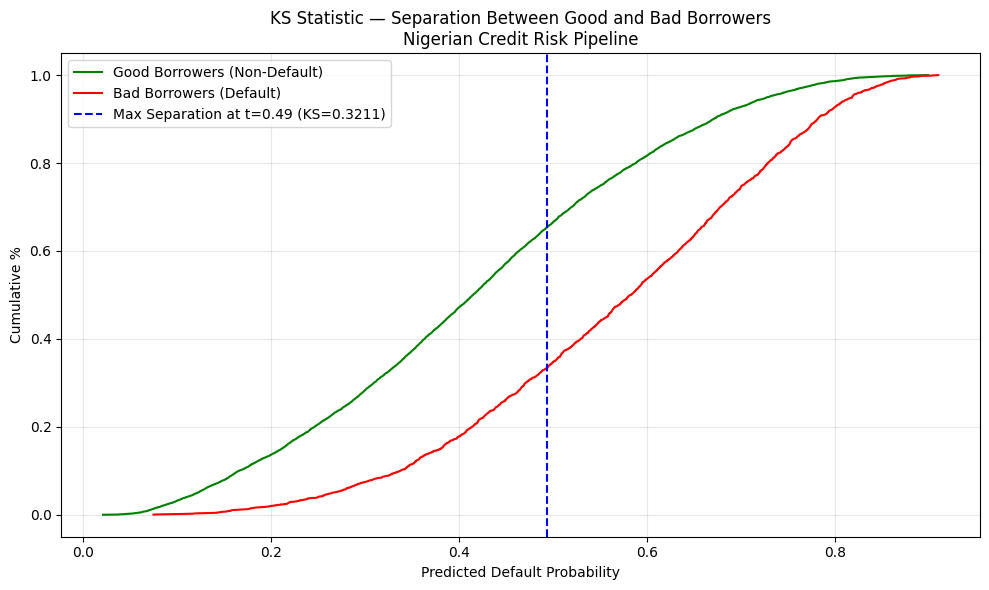

Threshold with maximum separation: 0.4935


In [6]:
# Find the threshold with the widest gap
ks_thresholds = np.linspace(0, 1, 1000)
gaps = []

for t in ks_thresholds:
    good_cdf_at_t = (good_scores <= t).mean()
    bad_cdf_at_t = (bad_scores <= t).mean()
    gaps.append(abs(bad_cdf_at_t - good_cdf_at_t))

ks_threshold = ks_thresholds[np.argmax(gaps)]

# Plot
plt.figure(figsize=(10, 6))

good_sorted = np.sort(good_scores)
bad_sorted = np.sort(bad_scores)

good_cdf = np.arange(1, len(good_sorted) + 1) / len(good_sorted)
bad_cdf = np.arange(1, len(bad_sorted) + 1) / len(bad_sorted)

plt.plot(good_sorted, good_cdf, label='Good Borrowers (Non-Default)', color='green')
plt.plot(bad_sorted, bad_cdf, label='Bad Borrowers (Default)', color='red')

plt.axvline(x=ks_threshold, color='blue', linestyle='--', 
            label=f'Max Separation at t={ks_threshold:.2f} (KS={ks_stat:.4f})')

plt.xlabel('Predicted Default Probability')
plt.ylabel('Cumulative %')
plt.title('KS Statistic — Separation Between Good and Bad Borrowers\nNigerian Credit Risk Pipeline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Threshold with maximum separation: {ks_threshold:.4f}")

### KS Statistic Interpretation

The KS plot shows the cumulative distribution of predicted default probabilities 
for good borrowers (non-defaulters) and bad borrowers (defaulters).

**KS Statistic: 0.3211 (32.11%)** — Acceptable separation for a credit risk model.

**Reading the chart:**
- The green curve rises steeply early — most good borrowers receive low 
  default probability scores, which is correct behaviour
- The red curve rises more slowly — defaulters tend to receive higher 
  probability scores, which is correct behaviour
- The blue dashed line at **t=0.49** marks the point of maximum separation 
  between the two groups

**At the KS threshold (t=0.49):**
- ~65% of good borrowers score below 0.49
- ~33% of bad borrowers score below 0.49
- Gap of 32 percentage points — this is the KS statistic

**Alignment with ROC curve:**
The KS threshold of 0.49 aligns with the ROC curve operating point at t=0.49 
(TPR=0.67, FPR=0.35) — both metrics independently identify the same optimal 
operating point, reinforcing confidence in this threshold for lending decisions.

**In Nigerian fintech context:**
A KS of 32% means the model provides meaningful signal for loan approval 
decisions. Nigerian digital lenders typically validate scorecards using KS 
as the primary metric before deployment — a KS above 20% is considered 
the minimum bar for a production credit model.

## Confusion Matrix at Different Thresholds

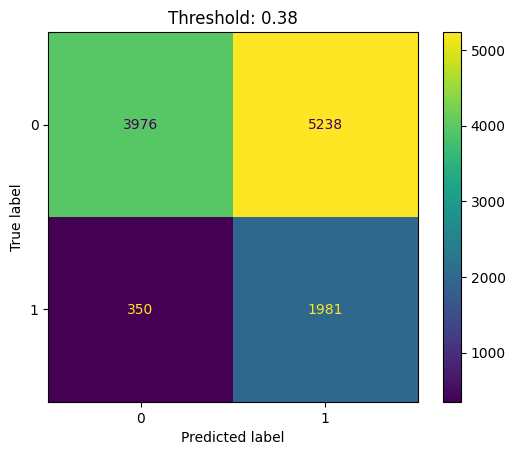


Threshold: 0.38
              precision    recall  f1-score   support

           0       0.92      0.43      0.59      9214
           1       0.27      0.85      0.41      2331

    accuracy                           0.52     11545
   macro avg       0.60      0.64      0.50     11545
weighted avg       0.79      0.52      0.55     11545



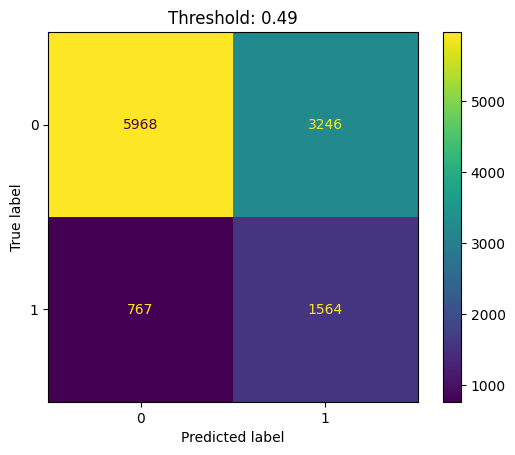


Threshold: 0.49
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      9214
           1       0.33      0.67      0.44      2331

    accuracy                           0.65     11545
   macro avg       0.61      0.66      0.59     11545
weighted avg       0.77      0.65      0.69     11545



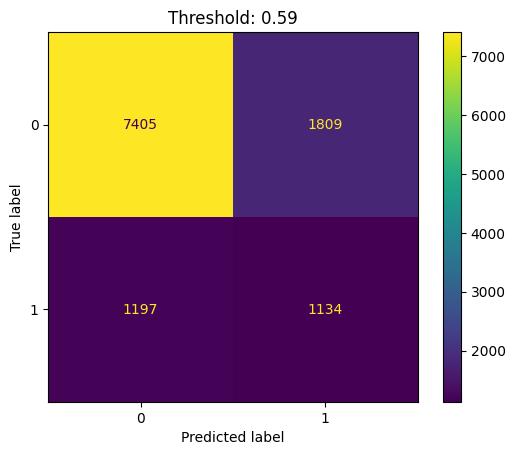


Threshold: 0.59
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      9214
           1       0.39      0.49      0.43      2331

    accuracy                           0.74     11545
   macro avg       0.62      0.65      0.63     11545
weighted avg       0.76      0.74      0.75     11545



In [7]:
# Threshold 1: 0.38
y_pred_38 = (y_pred_proba >= 0.38).astype(int)
cm38 = confusion_matrix(y_test, y_pred_38)
ConfusionMatrixDisplay(cm38).plot()
plt.title('Threshold: 0.38')
plt.show()
print(f"\nThreshold: 0.38")
print(classification_report(y_test, y_pred_38))

# Threshold 2: 0.49
y_pred_49 = (y_pred_proba >= 0.49).astype(int)
cm49 = confusion_matrix(y_test, y_pred_49)
ConfusionMatrixDisplay(cm49).plot()
plt.title('Threshold: 0.49')
plt.show()
print(f"\nThreshold: 0.49")
print(classification_report(y_test, y_pred_49))

# Threshold 3: 0.59
y_pred_59 = (y_pred_proba >= 0.59).astype(int)
cm59 = confusion_matrix(y_test, y_pred_59)
ConfusionMatrixDisplay(cm59).plot()
plt.title('Threshold: 0.59')
plt.show()
print(f"\nThreshold: 0.59")
print(classification_report(y_test, y_pred_59))

### Confusion Matrix — Threshold Analysis

| Threshold | Default Catch Rate (Recall) | Precision on Defaults | Accuracy | f1 | Business Profile |
|---|---|---|---|---|---|
| 0.38 | 85% | 27% | 52% | 41% | Aggressive |
| 0.49 | 67% | 33% | 65% | 44% | Balanced |
| 0.59 | 49% | 39% | 74% | 43%| Conservative |

**What the above table means:**

At **t=0.38** — the model catches 85% of all defaulters but only 27% of the borrowers it flags as risky actually default. This means a lot of good borrowers get rejected. A lender in a high NPL environment might accept this tradeoff to protect their loan book.

At **t=0.49** — catches 67% of defaulters with better precision at 33%. Overall accuracy jumps to 65%. This is the balanced operating point confirmed by both the ROC curve and KS statistic independently.

At **t=0.59** — catches only 49% of defaulters but with the highest precision at 39% and best overall accuracy at 74%. A growth-focused lender trying to maximise approvals while keeping some risk control might prefer this.

**Recommended threshold: t=0.49** — supported by three independent signals: ROC curve operating point, KS maximum separation point, and best F1 balance in the classification report.

**Note on F1 scores:** The F1 scores for default detection are similar across 
all thresholds (41% - 44%), confirming that threshold selection should be driven 
by business risk appetite rather than F1 alone. The recommended t=0.49 offers 
the best overall balance across all four metrics.

## Feature Importance

In [8]:
# Extract the XGBoost model from the pipeline
xgb_model = model.named_steps['model']

# Extract feature names from the preprocessor
cat_features = model.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .named_steps['cat']\
    .get_feature_names_out(categorical)

all_features = list(cat_features) + numerical

# Get importances
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

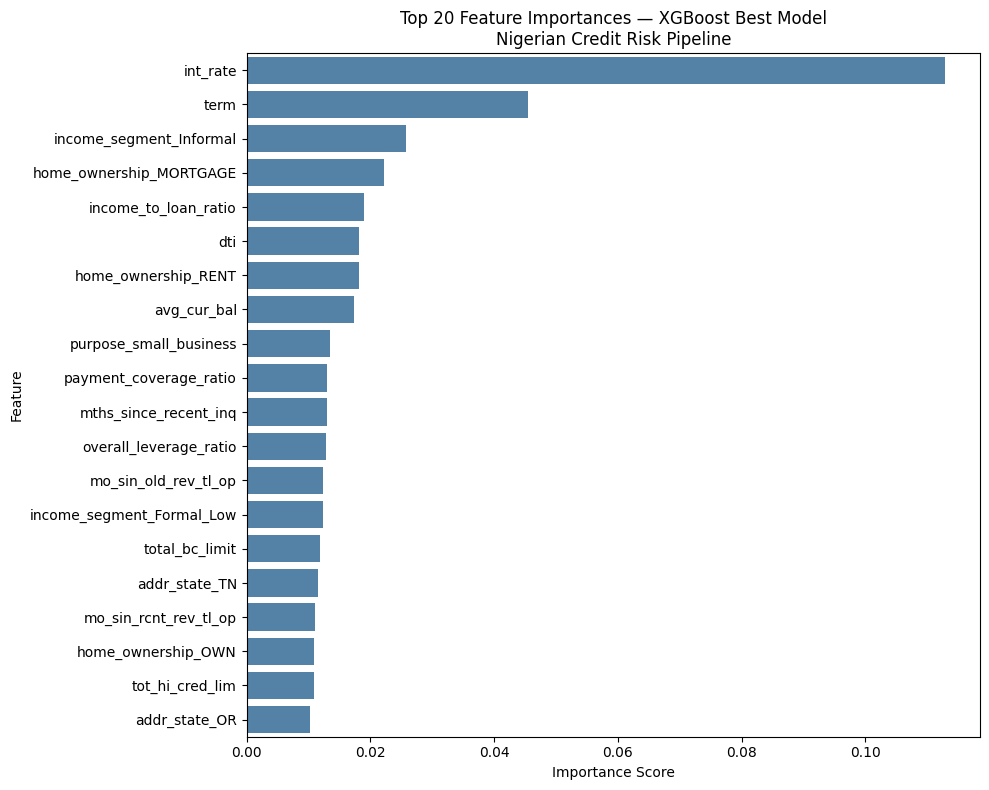

In [9]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df, x='importance', y='feature', color='steelblue')
plt.title('Top 20 Feature Importances — XGBoost Best Model\nNigerian Credit Risk Pipeline')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The chart shows the top 20 features driving default prediction in the 
XGBoost champion model, ranked by importance score.

**Top 5 Features:**

**1. `int_rate` (Interest Rate)** — By far the strongest predictor of default.
Higher interest rates are assigned to riskier borrowers by lenders, meaning 
the rate itself encodes credit risk. In a Nigerian fintech context this maps 
to the pricing tier assigned during loan origination.

**2. `term`** — Longer loan terms correlate with higher default risk. 
Borrowers on 60-month loans default more than those on 36-month loans, 
reflecting the increased uncertainty over longer repayment periods.

**3. `income_segment_Informal`** — The third most important feature is one 
engineered specifically for the Nigerian context. Borrowers with unverified 
income — mapped to informal earners without IPPIS or payroll verification — 
are significantly more likely to default. This validates the Nigerian 
income segmentation feature engineering.

**4. `home_ownership_MORTGAGE` and `home_ownership_RENT`** — Housing 
stability is predictive of repayment behaviour. Mortgage holders show 
different default patterns to renters, reflecting financial commitment 
and stability levels.

**5. `income_to_loan_ratio` and `payment_coverage_ratio`** — Two engineered 
affordability features appear in the top 10, directly validating the SQL 
feature engineering step. Borrowers whose income poorly covers their loan 
amount or monthly payment are at higher default risk.

**`dti` (Debt-to-Income Ratio)** — Confirms that overall debt burden is 
a meaningful default signal, consistent with CBN guidelines on debt 
service thresholds.

**Note on geographic features:**
`addr_state_TN` and `addr_state_OR` appear in the top 20 but likely 
represent noise — U.S. state is not a meaningful feature in a Nigerian 
lending context. In a production Nigerian pipeline these would be replaced 
with Nigerian state or geopolitical zone, which carries genuine regional 
credit risk signal.

**Key takeaway:** The model rewards both raw borrower data (interest rate, 
DTI, term) and engineered features (income segment, affordability ratios), 
confirming that the SQL feature engineering step added genuine predictive 
value beyond the original dataset.